# Clase 9 - Redes Convolucionales - Diplomado Inteligencia Artificial UC
En este laboratorio exploraremos técnicas de visualización en redes neuronales, tanto de sus representaciones internas (feature visualization) como qué partes del input son responsables del output (attribution).

**Nombre : Johnny Huincahue**

In [14]:
# @title
# Librerías
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Resize, Normalize
from os import listdir
from os.path import join
from PIL import ImageShow
from lucent.optvis import render
ImageShow._viewers = [ImageShow.IPythonViewer()]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Datos y utilidad de evaluación
!wget https://www.dropbox.com/s/jxk9m5d2umscr1a/lab1_CNN_IA.zip
!unzip lab1_CNN_IA.zip
!tar -xzf flowers.tar.gz

from test_model import test_model

# Dataset de flores
class Flowers(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.imagenes = []
        self.imgs_to_class = []
        self.imagenes, self.imgs_to_class = self.armar_indices(root)

    def armar_indices(self, root):
        n_classes = len(listdir(root))
        contador = 0
        lista_imagenes = []
        imgs_to_class = []
        for clase in sorted(listdir(root)):
            directorio = join(root, clase)
            for archivo in sorted(listdir(directorio)):
                lista_imagenes.append(archivo)
                contador += 1
                imgs_to_class.append(int(clase))
        return lista_imagenes, imgs_to_class

    def obtener_imagen(self, archivo):
        im = Image.open(archivo)
        return im

    def __getitem__(self, idx):
        nombre_archivo = self.imagenes[idx]
        clase = self.imgs_to_class[idx]
        ruta_img = join(self.root, str(clase))
        ruta_img = join(ruta_img, nombre_archivo)
        img = self.obtener_imagen(ruta_img)
        if self.transform is not None:
            img = self.transform(img)
        return img, clase

    def __len__(self):
        return len(self.imagenes)
def get_images(model, layers, rows, cols, preprocess=True, transforms=None):
    fig = plt.figure(figsize=(4*len(layers)*cols, 4*rows))
    outer_grid = fig.add_gridspec(1, len(layers))
    for layer_index, layer in enumerate(layers):
        inner_grid = outer_grid[0, layer_index].subgridspec(rows, cols, wspace=0, hspace=0)
        axs = inner_grid.subplots()
        for i in range(rows):
            for j in range(cols):
                image = render.render_vis(model, f'{layer}:{i*cols+j}', preprocess=preprocess, transforms=transforms, show_image=False)[0][0]
                ax = axs[i][j]
                ax.imshow(image)
                if i == (rows-1) and j == cols//2:
                    ax.set_xlabel(layer, fontsize=18)
                ax.set(xticks=[], yticks=[])
    plt.show()

--2026-08-24 01:26:45--  https://www.dropbox.com/s/jxk9m5d2umscr1a/lab1_CNN_IA.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/gr8iqocnq4628s440h48m/lab1_CNN_IA.zip?rlkey=2zfvq9ke7i58i70q9k9abcar9 [following]
--2026-08-24 01:26:45--  https://www.dropbox.com/scl/fi/gr8iqocnq4628s440h48m/lab1_CNN_IA.zip?rlkey=2zfvq9ke7i58i70q9k9abcar9
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4b98322d3023e55525196cffcb.dl.dropboxusercontent.com/cd/0/inline/DGylcKNXSnQoggCsUqSQnsZ3kPn_F1NFq5nrDhz1ik0saLWZr5HNgp5IUB4TDBfQL98hHP7gtyi_I3wStoQmxnBgAkaE90CIrR05h0HBe_O7Btasty47P_2T0xWKG3yEQHGB1-f0-Cx6CU89iQ0btV8z/file# [following]
--2026-08-24 01:26:46--  https://uc4b98322d3023e55525196cffcb.dl.dropboxusercontent.com/c

# Actividades

### Actividad 1
Escoja una de las arquitecturas entre vgg19, googlenet y resnet50 y modifíquela según las instrucciones a continuación para que sea compatible con la cantidad de clases en el dataset de las flores.

In [ ]:
# escogemos esta arquitectura
!wget https://www.dropbox.com/s/q308auknnt8szzw/base_resnet50.pth

import gc
gc.collect()
torch.cuda.empty_cache()

base_resnet50 = models.resnet50()
base_resnet50.fc = nn.Linear(2048, 102)
base_resnet50.load_state_dict(torch.load("base_resnet50.pth"))
base_resnet50 = base_resnet50.to(device).eval()

transforms = Compose([Resize((224, 224)), ToTensor()])
ds_train = Flowers("flowers_dataset/train", transform=transforms)
train_dl = DataLoader(ds_train, batch_size=32)
ds_test = Flowers("flowers_dataset/test", transform=transforms)
test_dl = DataLoader(ds_test, batch_size=32)

print("TRAIN:")
test_model(base_resnet50, train_dl)

print("TEST:")
test_model(base_resnet50, test_dl)


TRAIN:
Correctas: 5222.0 Total: 5687.0 Accuracy: 91.82%
TEST:
Correctas: 2194.0 Total: 2666.0 Accuracy: 82.30%

Se observan que los resultadores fueron:

* Train: 91.82%
* Test: 82.30%

Con una diferencia de casi 10%, posiblemente indicando un sobreajuste del modelo.

### Actividad 2

Visualice 4 canales de la primera capa convolucional, una capa de al medio y la última capa convolucional para su modelo entrenado. ¿Cómo son los features? ¿Se aprecia un aumento en la complejidad de los features a medida que las capas son más profundas?

  Recuerde que si no normaliza el input, entonces debe entregar el parámetro `preprocess=False` a las funciones que generan las imágenes.

100%|██████████| 512/512 [00:13<00:00, 37.07it/s]


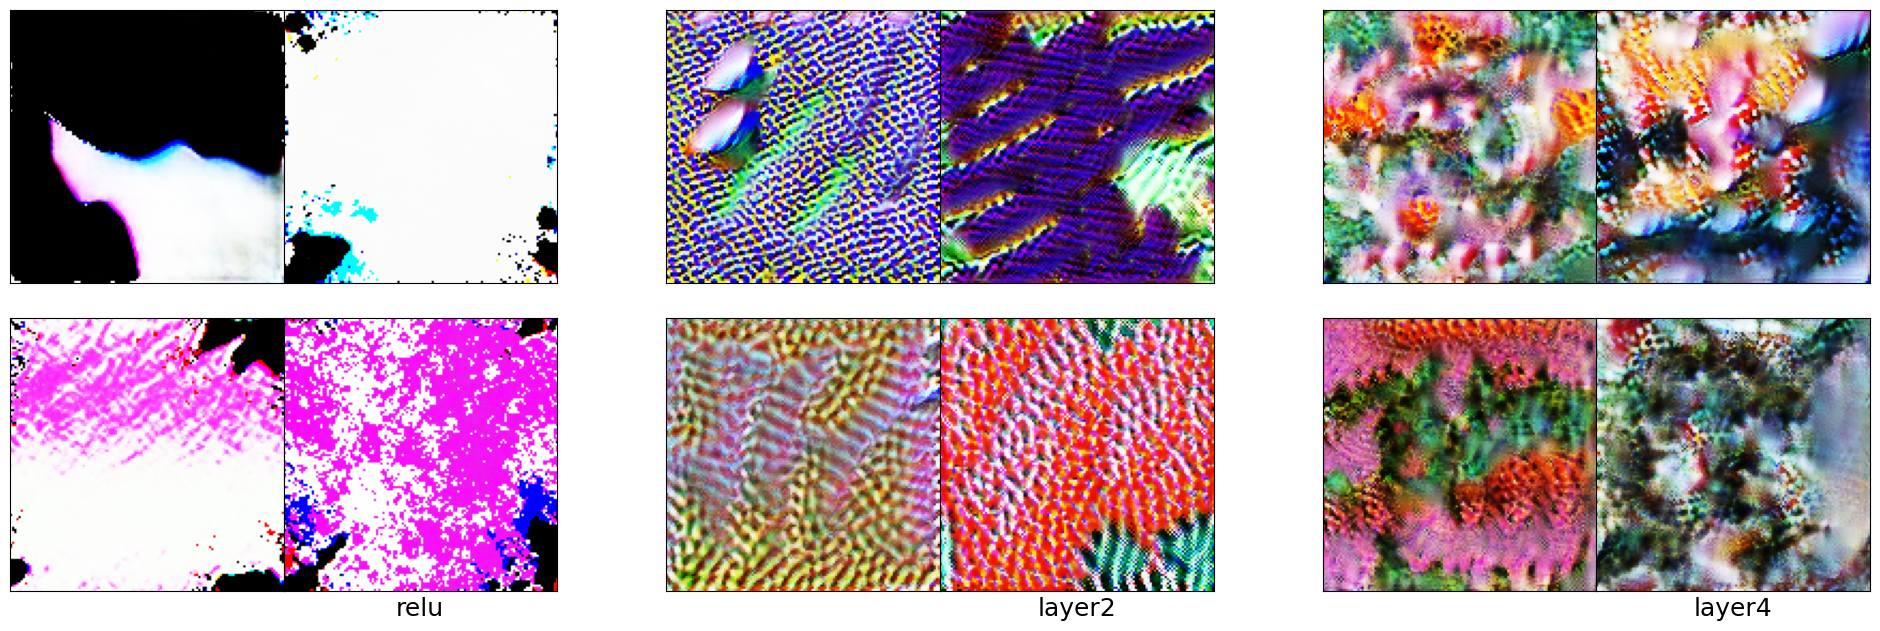

In [16]:
# Primera capa, capa intermedia y última capa convolucional (4 canales -> grilla 2x2)
get_images(base_resnet50, ['relu', 'layer2', 'layer4'], 2, 2, preprocess=False)

En la primera capa se ven imágenes muy básicas, como manchas de color negro y rosado, quizás constrastando solo cosas simples como colores.

Luego en la capa 2 se observan más colores y texturas, formando patrones un poco más complejos.

Por último, en la última capa las imagenes parecieran tomar una forma más elaborada, mezclando más colores y formas que parecen parte de algún objeto.

También podemos observar que aumentando la complejidad de los features las capas aprenden a detectar patrones más complejos.

### Actividad 3

Escoja 3 flores y visualice la imagen generada para cada una de las flores en su modelo entrenado. ¿Tienen sentido las imágenes generadas?

  Recuerde que si no normaliza el input, entonces debe entregar el parámetro `preprocess=False` a las funciones que generan las imágenes.

100%|██████████| 512/512 [00:15<00:00, 33.64it/s]


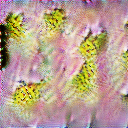

100%|██████████| 512/512 [00:15<00:00, 32.62it/s]


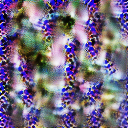

100%|██████████| 512/512 [00:14<00:00, 35.23it/s]


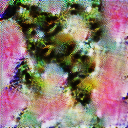

In [23]:
# 3 flores escogidas (clases 0, 8 y 50).
for clase in [0, 8, 50]:
    _ = render.render_vis(base_resnet50, f'labels:{clase}', preprocess=False, show_image=True)

En este caso, las imágenes no tienen mucho sentido visual. esto a que el modelo fue entrenado desde cero y con pocos datos, asi que podría estar memorizando detalles sueltos del dataset.

### Actividad 4
Ocupe la versión preentrenada en ImageNet del modelo que escogió y entrene por al menos 20 épocas el modelo en el Flower dataset. ¿Qué resultados obtiene en train y test?

  El siguiente código muestra las modificaciones necesarias al modelo para utilizar los pesos preentrenados como base


In [18]:
# Resnet50 preentrenada en ImageNet, base congelada, solo entrenamos la capa final
finetuned_resnet50 = models.resnet50(weights="IMAGENET1K_V1")
for param in finetuned_resnet50.parameters():
    param.requires_grad = False
finetuned_resnet50.fc = nn.Linear(2048, 102)
finetuned_resnet50 = finetuned_resnet50.to(device)

# Con pesos de ImageNet usamos datos normalizados
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transforms = Compose([Resize((224, 224)), ToTensor(), Normalize(mean, std)])
normalized_train_dataset = Flowers("flowers_dataset/train", transform=transforms)
normalized_test_dataset = Flowers("flowers_dataset/test", transform=transforms)
normalized_train_dl = DataLoader(normalized_train_dataset, batch_size=256, shuffle=True)
normalized_test_dl = DataLoader(normalized_test_dataset, batch_size=256)

# Entrenamiento por 20 épocas (solo la capa final)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(finetuned_resnet50.fc.parameters(), lr=1e-3)

finetuned_resnet50.train()
for epoca in range(20):
    perdida_total = 0.0
    for x, target in normalized_train_dl:
        x, target = x.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(finetuned_resnet50(x), target)
        loss.backward()
        optimizer.step()
        perdida_total += loss.item()
    print(f"Epoca {epoca+1}: Loss: {perdida_total/len(normalized_train_dl):.4f}")

finetuned_resnet50.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Epoca 1: Loss: 3.4757
Epoca 2: Loss: 1.6856
Epoca 3: Loss: 0.9619
Epoca 4: Loss: 0.6591
Epoca 5: Loss: 0.5035
Epoca 6: Loss: 0.3965
Epoca 7: Loss: 0.3367
Epoca 8: Loss: 0.2881
Epoca 9: Loss: 0.2477
Epoca 10: Loss: 0.2145
Epoca 11: Loss: 0.1895
Epoca 12: Loss: 0.1638
Epoca 13: Loss: 0.1514
Epoca 14: Loss: 0.1359
Epoca 15: Loss: 0.1251
Epoca 16: Loss: 0.1083
Epoca 17: Loss: 0.0999
Epoca 18: Loss: 0.0941
Epoca 19: Loss: 0.0843
Epoca 20: Loss: 0.0783
Correctas: 2603.0 Total: 2666.0 Accuracy: 97.64%

In [26]:
import gc
gc.collect()
torch.cuda.empty_cache()
eval_train_dl = DataLoader(normalized_train_dataset, batch_size=32)
eval_test_dl = DataLoader(normalized_test_dataset, batch_size=32)

print("\nTRAIN:")
test_model(finetuned_resnet50, eval_train_dl)

print("\nTEST:")
test_model(finetuned_resnet50, eval_test_dl)

TRAIN:
Correctas: 5676.0 Total: 5687.0 Accuracy: 99.81%TEST:
Correctas: 2603.0 Total: 2666.0 Accuracy: 97.64%

Luego de entrenar el modelo preentrenado por 20 epocas, se observa una baja en cada epoca del loss. Esto muestra que el modelo aprendio bien durante el entrenamiento.

Además lo resultados obtenidos fueron:

* Train: 99.81%
* Test: 97.64%

Valores bastante altos y cernanos entre sí, lo que sugiere que el modelo aprendio bien teniendo además una buena capacidad de generalizar.

### Actividad 5
Visualice las imágenes generadas para las 3 flores que escogió en la actividad 3 ahora en su nuevo modelo entrenado. Compare con las imágenes obtenidas en la actividad 3.

100%|██████████| 512/512 [00:13<00:00, 37.04it/s]


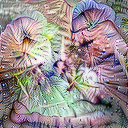

100%|██████████| 512/512 [00:13<00:00, 38.05it/s]


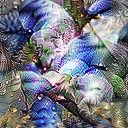

100%|██████████| 512/512 [00:14<00:00, 36.03it/s]


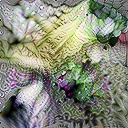

In [27]:
# Las mismas 3 flores de la Actividad 3, ahora en el modelo con finetuning
# Este modelo usa datos normalizados -> omitimos preprocess (queda True por default)
for clase in [0, 8, 50]:
    _ = render.render_vis(finetuned_resnet50, f'labels:{clase}', show_image=True)

Podemos observar que con el modelo entrenado a partir de ImageNet, las imagenes se observar más elaboradas que en la actividad 3. Aparecen formas más "definidas" a comparación de los otros, como en la primera imagen que pueden notarse algunos pétalos.